# Ch9 & 10 실습: 가설검정의 함정과 인과관계 추론

지난 시간, 우리는 `statsmodels`를 이용해 다양한 회귀 모델을 만드는 법을 배웠습니다. 오늘은 한 걸음 더 나아가, 통계 분석 결과를 해석할 때 빠지기 쉬운 함정들을 직접 코드로 체험하고, '상관관계'를 넘어 '인과관계'에 다가가는 고급 분석 기법들을 실습해 봅니다.

**학습 목표:**

1.  **허위 상관(Spurious Correlation)**과 **중첩요인(Confounder)**의 개념을 이해하고, 다중회귀로 중첩요인의 효과를 통제하는 법을 배웁니다.
2.  **p-해킹**과 **표본 크기의 함정**이 왜 위험한지 시뮬레이션을 통해 직접 증명합니다.
3.  실험이 불가능한 상황에서 인과 효과를 추정하는 강력한 도구, **경향 점수 짝짓기(PSM)**와 **이중차분법(DiD)**을 직접 구현해 봅니다.


## 사전 준비: 라이브러리 및 데이터 로드


In [ ]:
# 필요 라이브러리 설치
!pip install statsmodels scikit-learn

# 코랩에서 한글 폰트 사용을 위한 설정 (필요 시 주석 해제 후 실행)
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf
# 위 코드 실행 후 상단 메뉴에서 [런타임] > [런타임 다시 시작]을 눌러주세요.

In [ ]:
# 런타임 다시 시작 후, 이 셀을 실행하여 라이브러리와 폰트를 로드합니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.neighbors import NearestNeighbors

# 한글 폰트 설정 (Mac 사용자는 'AppleGothic', Windows 사용자는 'Malgun Gothic' 등)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

available_fonts = [f.name for f in fm.fontManager.ttflist]

if 'NanumGothic' in available_fonts:
    plt.rc('font', family='NanumGothic')
elif 'Apple SD Gothic Neo' in available_fonts:
    plt.rc('font', family='Apple SD Gothic Neo')
elif 'Noto Sans CJK KR' in available_fonts:
    plt.rc('font', family='Noto Sans CJK KR')

plt.rcParams['axes.unicode_minus'] = False

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

---


## 문제 1 (난이도: 하): 허위 상관과 중첩요인 통제하기

> **🎯 목표:** '아이스크림 판매량과 익사자 수'의 관계처럼, **허위 상관(Spurious Correlation)**이 발생하는 원인인 **중첩요인(Confounder)**을 이해하고, 다중회귀분석을 통해 그 효과를 통제하는 방법을 실습합니다.


### 💡 핵심 개념:

**허위 상관**은 두 변수 사이에 직접적인 인과관계가 없지만, '기온'과 같은 제3의 변수(중첩요인)가 두 변수 모두에 영향을 주어 마치 관계가 있는 것처럼 보이는 현상입니다. **다중회귀분석**에 중첩요인을 함께 투입하면, 다른 변수들의 영향을 고정한 상태에서의 '순수한' 관계를 파악할 수 있습니다.


### 📌 수행 과제:

1.  가상의 데이터를 생성합니다: '기온'이 높아질수록 '아이스크림 판매량'과 '해수욕객 수'가 모두 증가하는 상황을 시뮬레이션합니다.
2.  **단순회귀분석**: '아이스크림 판매량'만으로 '해수욕객 수'를 예측하는 모델을 만듭니다. 계수가 유의미하게 나오는지 확인합니다.
3.  **다중회귀분석**: '아이스크림 판매량'과 '기온'을 모두 사용하여 '해수욕객 수'를 예측하는 모델을 만듭니다.
4.  두 모델의 결과를 비교하고, '아이스크림 판매량'의 계수(coef)와 p-value가 어떻게 변했는지 해석해 보세요.


In [ ]:
# 1. 가상 데이터 생성 (이 코드는 수정하지 마세요)
np.random.seed(42)
n_samples = 100
temperature = np.random.uniform(15, 35, n_samples)
ice_cream_sales = 2 * temperature + np.random.normal(0, 5, n_samples)
beach_visitors = 10 * temperature + np.random.normal(0, 20, n_samples)
df1 = pd.DataFrame({'기온': temperature, '아이스크림판매량': ice_cream_sales, '해수욕객수': beach_visitors})
print(df1.corr())

# 2. 단순회귀분석: 아이스크림판매량 -> 해수욕객수
print("\n--- 모델 1: 단순회귀분석 (아이스크림판매량 -> 해수욕객수) ---")
y = df1['해수욕객수']
# 독립변수로 '아이스크림판매량'만 선택하세요.
X_simple = df1[['아이스크림판매량']]
# X_simple에 상수항을 추가하세요.
X_simple_const = sm.add_constant(X_simple)
# OLS 모델을 y와 X_simple_const로 학습시키세요.
model_simple = sm.OLS(y, X_simple_const).fit()
print(model_simple.summary())

# 3. 다중회귀분석: (아이스크림판매량, 기온) -> 해수욕객수
print("\n--- 모델 2: 다중회귀분석 (중첩요인 '기온' 통제) ---")
# 독립변수로 '아이스크림판매량'과 '기온'을 모두 선택하세요.
X_multi = df1[['아이스크림판매량','기온']]
# X_multi에 상수항을 추가하세요.
X_multi_const = sm.add_constant(X_multi)
# OLS 모델을 y와 X_multi_const로 학습시키세요.
model_multi = sm.OLS(y, X_multi_const).fit()
print(model_multi.summary())

# 4. 결과 해석 (아래 주석에 직접 작성해 보세요)
# 모델 1에서 아이스크림판매량의 계수와 p-value: 4.555 , 0.000
# 모델 2에서 아이스크림판매량의 계수와 p-value: -0.1087, 0.826
# 결과가 변한 이유: 기온이 중첩요인이라면 단순회귀에선 그게 누락되었기 때문에 왜곡된 값이 나옴.
#왜냐면 다중회귀 계수는 다른 변수를 고정한 조건부 효과를 의미하므로, 그 결과 아이스크림판매량 자체의 독립적인 영향은 통계적으로 유의하지 않다.

                기온  아이스크림판매량     해수욕객수
기온        1.000000  0.927709  0.938317
아이스크림판매량  0.927709  1.000000  0.867599
해수욕객수     0.938317  0.867599  1.000000

--- 모델 1: 단순회귀분석 (아이스크림판매량 -> 해수욕객수) ---
                            OLS Regression Results                            
Dep. Variable:                  해수욕객수   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     298.3
Date:                Fri, 19 Dec 2025   Prob (F-statistic):           1.70e-31
Time:                        08:01:56   Log-Likelihood:                -486.59
No. Observations:                 100   AIC:                             977.2
Df Residuals:                      98   BIC:                             982.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
            

### 🤔 생각해 볼 문제:

만약 '기온' 데이터를 수집하지 못했다면, 우리는 어떤 잘못된 결론에 도달할 위험이 있었을까요? 데이터 분석에서 '도메인 지식'이 왜 중요한지 이 사례를 통해 설명해 보세요.


데이터를 수집할 때 수집할 수 있는 항목에는 비용과 시간 등의 이유로 한계를 지닌다. <br>
따라서 도메인 지식이있다면 문제정의에 따라 원인 후보의 종류들을 이미 어느정도 알고 있을 것이고 변수간의 상관성에 대해서도 예상해볼 수 있을 것임. 즉, 데이터를 분석한 통계적 유의성만으로는 정확한 관계를 결정짓긴 위험이 있고하기 , 어떠한 변수의 순수한 효과를 판단하기 위해서는 통제적 변수에 대한 고려도 함께 할 줄 아는 도메인 지식이 필수적임.

---


## 문제 2 (난이도: 하): 표본 크기의 함정과 효과 크기의 중요성

> **🎯 목표:** 표본 크기(n)가 커지면 아주 미미한 차이도 통계적으로 유의(p<0.05)하게 되는 현상을 확인하고, 이 때문에 **효과 크기(Effect Size)**를 함께 확인해야 하는 이유를 이해합니다.


### 💡 핵심 개념:

가설검정에서 p-value는 '귀무가설이 맞다고 가정할 때, 현재 데이터와 같거나 더 극단적인 결과가 나올 확률'입니다. 표본이 커질수록 아주 작은 차이도 우연으로 보기 어려워지므로 p-value는 작아집니다. **효과 크기**는 이 차이가 '실질적으로 얼마나 의미 있는 크기인가'를 나타내는 지표로, p-value의 한계를 보완해 줍니다.


### 📌 수행 과제:

1.  평균이 아주 약간 다른(예: 170cm vs 170.1cm) 두 집단을 가정합니다.
2.  **작은 표본(n=30)**을 각 집단에서 추출하여 t-검정을 수행하고 p-value를 확인합니다.
3.  **큰 표본(n=10,000)**을 각 집단에서 추출하여 t-검정을 수행하고 p-value를 확인합니다.
4.  두 경우 모두에 대해 **효과 크기(Cohen's d)**를 직접 계산하고, p-value와 효과 크기가 어떻게 다른 메시지를 주는지 비교 분석하세요.


In [ ]:
# 효과 크기(Cohen's d) 계산 함수 (이 코드는 수정하지 마세요)
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

np.random.seed(123)
mu1, mu2, sigma = 170, 170.1, 5

# 2. 작은 표본(n=30)으로 검정
sample1_small = np.random.normal(mu1, sigma, 30)
sample2_small = np.random.normal(mu2, sigma, 30)

# scipy.stats.ttest_ind를 사용하여 두 작은 표본 간의 t-검정을 수행하세요.
t_stat_small, p_value_small = stats.ttest_ind(sample1_small, sample2_small)
effect_size_small = cohen_d(sample1_small, sample2_small)

print(f"--- 작은 표본 (n=30) 결과 ---")
print(f"P-value: {p_value_small:.4f}")
print(f"Effect Size (Cohen's d): {effect_size_small:.4f}\n")

# 3. 큰 표본(n=10000)으로 검정
sample1_large = np.random.normal(mu1, sigma, 10000)
sample2_large = np.random.normal(mu2, sigma, 10000)

# scipy.stats.ttest_ind를 사용하여 두 큰 표본 간의 t-검정을 수행하세요.
t_stat_large, p_value_large = stats.ttest_ind(sample1_large, sample2_large)
effect_size_large = cohen_d(sample1_large, sample2_large)

print(f"--- 큰 표본 (n=10000) 결과 ---")
print(f"P-value: {p_value_large:.4f}")
print(f"Effect Size (Cohen's d): {effect_size_large:.4f}\n")

# 4. 결과 해석 (아래 주석에 직접 작성해 보세요)
# 표본 크기가 커지자 p-value는 어떻게 변했나요?: 줄어들었음.
# 두 경우의 효과 크기는 비슷한가요, 다른가요?: 효과도 다르게 나왔음.
# 이 결과는 우리에게 무엇을 알려주나요?: 표본크기가 커질수록 p값이 작은 효과에 민감해져서 값이 작아진다.
#결국, 통계적 유의성만 보고 효과 유무를 판단하긴 어려우며 효과 크기를 함께 해석해야 한다.

--- 작은 표본 (n=30) 결과 ---
P-value: 0.7100
Effect Size (Cohen's d): -0.0965

--- 큰 표본 (n=10000) 결과 ---
P-value: 0.1673
Effect Size (Cohen's d): -0.0195



### 🤔 생각해 볼 문제:

A/B 테스트에서 웹사이트 버튼 색깔을 바꿨더니, 클릭률이 0.1%p 증가했고, p-value는 0.001이었습니다. 이 결과를 보고 버튼 색깔을 바꾸는 것이 항상 옳다고 할 수 있을까요? '통계적 유의성'과 '실무적 중요성(practical significance)'의 차이에 대해 효과 크기 개념을 바탕으로 설명해 보세요.


실무적으로 중요한 것은 일단 내용이고, 그 내용을 뒷받침할 수 있는 실험 설계가 올바르게 이루어졌는지, 귀무가설과 대립가설이 타당한지, 표본수는 어떠한지. 등 여러가지가 함께 고려되어야 합니다. 따라서 주로 실무에서 효과가 있다 없다를 볼 때 그 크기가 의미있는 크기인지를 함께 보고 통계적 유의성을 해석하는게 중요하겠습니다.
  

---


## 문제 3 (난이도: 중): p-해킹 시뮬레이션

> **🎯 목표:** '데이터를 보면서 분석을 계속할지 결정하는 행위'가 어떻게 잘못된 결론(제1종 오류)의 가능성을 높이는지, 즉 **p-해킹**의 위험성을 시뮬레이션을 통해 직접 증명합니다.


### 💡 핵심 개념:

**p-해킹**은 연구자가 의도했든 안 했든 p-value를 낮추기 위해 분석 과정을 조작하는 행위를 말합니다. 대표적인 예로, p-value가 0.05를 넘으면 표본을 더 모아서 다시 검정하는 행위가 있습니다. 원래 제1종 오류(실제 차이가 없는데, 차이가 있다고 결론 내릴 오류) 확률은 유의수준 α(보통 0.05)로 통제되어야 하지만, p-해킹은 이 확률을 α보다 훨씬 높게 만듭니다.


### 📌 수행 과제:

1.  **아무 차이가 없는** 두 집단 A, B를 가정합니다 (귀무가설이 참인 상황).
2.  'p-해커'를 시뮬레이션하는 함수를 만듭니다. 이 함수는 다음 로직을 따릅니다:
    - 먼저 각 집단에서 20명씩 표본을 추출하여 t-검정을 합니다.
    - p < 0.05이면 '유의미한 결과 발견!'을 외치고 멈춥니다.
    - p >= 0.05이면, 10명씩 표본을 추가하여 다시 t-검정을 합니다. 이 과정을 최대 5번까지 반복합니다.
3.  이 시뮬레이션을 1,000번 반복하여, 'p-해커'가 결국 '유의미한 결과'를 발견할 확률이 몇 %인지 계산합니다.
4.  계산된 확률이 왜 5%보다 훨씬 높은지 설명하세요.


In [ ]:
# p-해킹 시뮬레이션 함수 (이 코드는 수정하지 마세요)
def p_hacking_simulation():
    mu, sigma = 0, 1 # 평균은 0이고 표준편차는 1인 정규분포 가정한다는 뜻이고 두 집단이 본질적으로 동일하다는 전제 설정
    sample_a, sample_b = list(np.random.normal(mu, sigma, 20)), list(np.random.normal(mu, sigma, 20))
    for i in range(5):
        t_stat, p_val = stats.ttest_ind(sample_a, sample_b)
        if p_val < 0.05:
            return True # p-해킹 성공!
        if i < 4:
            sample_a.extend(np.random.normal(mu, sigma, 10))
            sample_b.extend(np.random.normal(mu, sigma, 10))
    return False # 5번 시도 모두 실패

# 3. 시뮬레이션 1000번 실행
n_simulations = 1000
p_hacking_success_count = 0

# for문을 사용하여 시뮬레이션을 1000번 반복하세요.
for _ in range(n_simulations):
    if p_hacking_simulation():  # 함수를 호출하고, 결과가 True이면 (p-해킹에 성공하면)
       p_hacking_success_count += 1   #1 증가시키세요.


type_1_error_rate = p_hacking_success_count / n_simulations
print(f"관찰된 제1종 오류율: {type_1_error_rate * 100:.2f}%")

# 4. 결과 해석 (아래 주석에 직접 작성해 보세요)
# 제1종 오류율이 5%보다 훨씬 높게 나온 이유는?:
# (답) 처음에는 (실제로는 같은 집단) 각 그룹별 표본 20명 *5회 검정 반복하기였다가 p값이 0,05 이하가 나올 때까지 표본수 10씩 늘렸음.
# 이걸 1000번 반복했을 때 (아무 효과가 사실 없어야 하는데) p해커가 유의미하다고 착각한 비율 ()=1종오류율)이 11.5%로 나왔음.
# 이론적으로라면 5%만 나왔어야 하는데 훨씬 높게 나온 이유는 될 때까지 표본수를 늘리며 질문을 여러번 던지고 성공을 골랐기 때문이다.
# 이러한 연구 방식(p-해킹)이 '재현성 위기'를 초래하는 이유는?: P-해킹에 의한 유의미한 결과는 1종 류 확률 커진 우연에 의한 거짓 양성일 가능성이 높기 때문에
#동일 연구를 한 번 다시 수행할 때 같은 결과가 재현되지 않을 확률이 높다.

관찰된 제1종 오류율: 11.50%


### 🤔 생각해 볼 문제:

p-해킹을 막기 위한 현실적인 방법 중 하나는 **'사전 등록(Preregistration)'** 입니다. 연구를 시작하기 전에 '표본 크기는 몇으로 할 것이며, 어떤 분석을 할 것이다'라고 미리 공개적으로 약속하는 것입니다. 이 방법이 위 시뮬레이션에서 보여준 p-해킹 문제를 어떻게 방지할 수 있을지 설명해 보세요.


결과 수정을 금하기 위해서, 데이터를 오픈하기 전에 규칙을 고정하기 위한 방법임. 왜냐면 p해킹은 데이터를 본 뒤 이루어지기 때문임. 사전등록에서 표본 크기를 고정하고, 분석방법과 가설을 고정하는 것은 중간에 보면서 수정하는 과정 자체를 방지할 수 있음.

---


## 문제 4 (난이도: 중): 경향 점수 짝짓기(PSM)로 인과 효과 추정하기

> **🎯 목표:** 무작위 통제 실험(RCT)이 불가능한 관찰 데이터에서, **선택 편향(Selection Bias)**을 통제하고 인과 효과를 추정하는 대표적인 방법인 **경향 점수 짝짓기(Propensity Score Matching, PSM)**를 직접 구현합니다.


### 💡 핵심 개념:

**PSM**은 '특정 처치(treatment)를 받을 경향'을 점수로 계산하여, 이 점수가 비슷한 실험군과 대조군 개체를 1:1로 짝지어주는 방법입니다. 이를 통해 처치 여부를 제외한 다른 특성(중첩요인)들이 비슷한, 즉 **'통계적 쌍둥이'** 집단을 만들 수 있습니다. 이 '짝지어진' 집단 간의 결과 차이를 비교하면, 선택 편향이 보정된 순수한 처치 효과에 더 가깝게 다가갈 수 있습니다.


### 📌 수행 과제:

1.  '새로운 온라인 강의 수강 여부'가 '기말고사 성적'에 미치는 영향을 분석하는 가상 데이터를 생성합니다. (단, '사전 성적'이 높고 '학습 의지'가 높은 학생일수록 강의를 신청할 확률이 높도록 **선택 편향**을 부여합니다.)
2.  **단순 비교**: 전체 수강생 집단과 비수강생 집단의 평균 성적을 비교합니다.
3.  **PSM 수행**:
    a. 로지스틱 회귀를 이용해 각 학생의 '강의 수강 경향 점수(propensity score)'를 계산합니다.
    b. 수강생(실험군) 한 명마다, 경향 점수가 가장 비슷한 비수강생(대조군)을 짝지어 줍니다. (`sklearn.neighbors.NearestNeighbors` 활용)
4.  **짝지어진 후 비교**: '짝지어진' 수강생 집단과 비수강생 집단의 평균 성적을 비교하고, 그 차이(ATT: Average Treatment Effect on the Treated)를 계산합니다.
5.  단순 비교 결과와 PSM 후의 결과를 비교하고, 왜 결과가 달라졌는지 해석합니다.


In [ ]:
# 1. 선택 편향이 있는 데이터 생성 (이 코드는 수정하지 마세요)
np.random.seed(42)
n = 1000  # 학생 1000명 생성
pre_score = np.random.normal(60, 10, n)  #사전 성적 평균 60, 표준편차 10
motivation = np.random.uniform(0, 1, n)  #학습의지는 0-1 사이
propensity = 1 / (1 + np.exp(-( -5 + (pre_score-60)/5 + motivation*2)))  #선택편향을 의도적으로 만듬
treatment = np.random.binomial(1, propensity, n)
true_effect = 5
final_score = pre_score + treatment * true_effect + np.random.normal(0, 5, n)
df4 = pd.DataFrame({'pre_score': pre_score, 'motivation': motivation, 'treatment': treatment, 'final_score': final_score})

# 2. 단순 비교 (Naive Effect)
naive_effect = df4[df4['treatment']==1]['final_score'].mean() - df4[df4['treatment']==0]['final_score'].mean()
print(f"단순 평균 비교 (성적 차이): {naive_effect:.2f}점\n")

# 3-a. 경향 점수 계산
X = df4[['pre_score', 'motivation']]
y = df4['treatment']
logit_model = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
df4['propensity_score'] = logit_model.predict(sm.add_constant(X))

# 3-b. 짝짓기 (Matching)
treated = df4[df4['treatment'] == 1]
control = df4[df4['treatment'] == 0]

# NearestNeighbors를 사용하여 control 그룹에서 treated 그룹과 가장 가까운 이웃 1명을 찾도록 설정하세요.
nn = NearestNeighbors(n_neighbors=1, radius=0.5)
# control 그룹의 경향 점수로 모델을 학습시키세요.
nn.fit(control[['propensity_score']])
# treated 그룹의 경향 점수를 기반으로 가장 가까운 이웃의 인덱스를 찾으세요.
distances, indices = nn.kneighbors(treated[['propensity_score']])

matched_control = control.iloc[indices.flatten()]

# 4. 짝지어진 후 비교 (ATT 계산)
# treated 그룹과 matched_control 그룹의 'final_score' 평균 차이를 계산하여 ATT를 구하세요.
att_effect = treated['final_score'].mean() - matched_control['final_score'].mean()
print(f"PSM 이후 평균 비교 (추정된 인과 효과): {att_effect:.2f}점\n")

# 5. 결과 해석 (아래 주석에 직접 작성해 보세요)
# 단순 비교 결과가 실제 효과(5점)보다 크게 나온 이유는?: 수강생 집단이 사전성적과 학습의지가 높은 학생들로 배치될 확률을 크게 만들었고,
#그 특성 자체가 기말 성적을 올리는데 기여할 수 있는 요인들이었기 때문이다. 단순 비교는 이러한 선택 편향을 통제하지 못해서 강의 효과와 학생 기존 특성 효과가 섞였다.
# PSM을 통해 이 문제를 어떻게 해결할 수 있었나요?: PSM(경향점수 짝짓기)을 통해 사전성적과 학습 의지가 유사한 수강색과 비수강생을 비슷한 수준으로 매칭하여 비교함.

단순 평균 비교 (성적 차이): 19.96점

PSM 이후 평균 비교 (추정된 인과 효과): 4.31점



### 🤔 생각해 볼 문제:

짝짓기(Matching)가 잘 되었는지 확인하는 방법 중 하나는, 짝지어진 두 집단의 중첩요인(여기서는 `pre_score`, `motivation`) 평균이 서로 비슷해졌는지 확인하는 것입니다. 이를 **'공변량 균형(Covariate Balance)'** 확인이라고 합니다. 짝짓기 전과 후의 `pre_score` 평균 차이를 각각 계산해보고, PSM이 공변량 균형을 맞추는 데 성공했는지 확인해보세요.


In [ ]:
# 짝짓기 전 평균값
before_summary = pd.DataFrame({
    'Group': ['Treated', 'Control'],
    'pre_score_mean': [
        treated['pre_score'].mean(),
        control['pre_score'].mean()
    ],
    'motivation_mean': [
        treated['motivation'].mean(),
        control['motivation'].mean()
    ]
})

print("=== Before Matching (원본 데이터) ===")
print(before_summary)

print("\n평균 차이 (Treated - Control)")
print(f"pre_score diff: {treated['pre_score'].mean() - control['pre_score'].mean():.2f}")
print(f"motivation diff: {treated['motivation'].mean() - control['motivation'].mean():.3f}")

# 짝짓기 후 평균값
after_summary = pd.DataFrame({
    'Group': ['Treated (matched)', 'Control (matched)'],
    'pre_score_mean': [
        treated['pre_score'].mean(),
        matched_control['pre_score'].mean()
    ],
    'motivation_mean': [
        treated['motivation'].mean(),
        matched_control['motivation'].mean()
    ]
})

print("\n=== After Matching (PSM 적용 후) ===")
print(after_summary)

print("\n평균 차이 (Treated - Control)")
print(f"pre_score diff: {treated['pre_score'].mean() - matched_control['pre_score'].mean():.2f}")
print(f"motivation diff: {treated['motivation'].mean() - matched_control['motivation'].mean():.3f}")


=== Before Matching (원본 데이터) ===
     Group  pre_score_mean  motivation_mean
0  Treated       74.016658         0.658001
1  Control       59.152854         0.492031

평균 차이 (Treated - Control)
pre_score diff: 14.86
motivation diff: 0.166

=== After Matching (PSM 적용 후) ===
               Group  pre_score_mean  motivation_mean
0  Treated (matched)       74.016658         0.658001
1  Control (matched)       74.391146         0.620370

평균 차이 (Treated - Control)
pre_score diff: -0.37
motivation diff: 0.038


PSM 적용 후 두 그룹간 사전성적과 의지점수의 평균이 비슷해진것을 확인할 수 있었음. 두 그룹의 선택편향이 사라져서 비슷한 조건에서 비교했음을 알 수 있음. PMS 이후 평균값이 위에서 4.31점으로 5점에 가깝게 변화했으므로 공변량 균형도 맞춰지는 쪽으로 개선되었다고 판단할 수 있음.

---


## 문제 5 (난이도: 상): 이중차분법(DiD)으로 정책 효과 분석하기

> **🎯 목표:** 특정 집단에만 시행된 정책의 효과를 분석하는 대표적인 준실험 방법론, **이중차분법(Difference-in-Differences, DiD)**을 회귀분석으로 구현하고 핵심 가정을 이해합니다.


### 💡 핵심 개념:

**이중차분법(DiD)**은 정책이 시행된 **실험군(Treatment Group)**과 시행되지 않은 **통제군(Control Group)**의 **정책 시행 전후(Pre-Post)** 데이터를 모두 활용하는 강력한 인과추론 방법입니다. 핵심 아이디어는 '정책이 없었을 경우의 자연적인 시간 변화'를 통제군을 통해 추정하고, 이를 실험군의 변화에서 빼 줌으로써 정책의 순수한 효과만 발라내는 것입니다. 회귀분석에서는 `(실험군 여부) * (정책 후 여부)`의 **상호작용 항** 계수가 바로 DiD 추정치가 됩니다.


### 📌 수행 과제:

1.  '서울시'에만 '무료 공공 와이파이' 정책을 도입했을 때, 시민들의 '월 평균 데이터 사용량'에 미치는 영향을 분석하는 가상 데이터를 생성합니다. (실험군: 서울, 통제군: 부산)
2.  **시각화**: 정책 시행 전후, 두 도시의 평균 데이터 사용량 변화를 꺾은선 그래프로 그려봅니다.
3.  **DiD 회귀분석**: `데이터사용량 ~ is_서울 + is_정책후 + is_서울*is_정책후` 형태의 회귀 모델을 만듭니다.
    - `is_서울`: 서울이면 1, 부산이면 0
    - `is_정책후`: 정책 시행 후(2024년)이면 1, 시행 전(2023년)이면 0
    - `is_서울*is_정책후`: 상호작용 항
4.  회귀분석 결과표에서 상호작용 항의 계수(coef)와 p-value를 확인하고, 정책의 효과를 해석해 보세요.


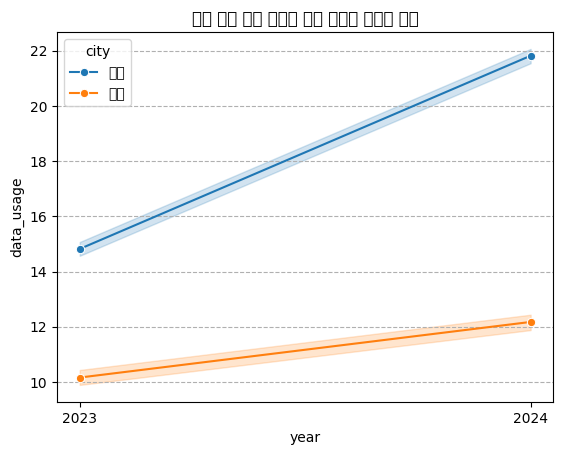

                            OLS Regression Results                            
Dep. Variable:             data_usage   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     1373.
Date:                Fri, 19 Dec 2025   Prob (F-statistic):               0.00
Time:                        08:05:15   Log-Likelihood:                -5079.1
No. Observations:                2000   AIC:                         1.017e+04
Df Residuals:                    1996   BIC:                         1.019e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.1600      0.137     74.006      0.0

In [ ]:
# 1. DiD 분석을 위한 가상 패널 데이터 생성 (이 코드는 수정하지 마세요)
np.random.seed(2025)
n_per_group = 500
df_seoul_pre = pd.DataFrame({'city': '서울', 'year': 2023, 'data_usage': np.random.normal(15, 3, n_per_group)})
df_seoul_post = pd.DataFrame({'city': '서울', 'year': 2024, 'data_usage': df_seoul_pre['data_usage'] + 2 + 5 + np.random.normal(0, 1, n_per_group)})
df_busan_pre = pd.DataFrame({'city': '부산', 'year': 2023, 'data_usage': np.random.normal(10, 3, n_per_group)})
df_busan_post = pd.DataFrame({'city': '부산', 'year': 2024, 'data_usage': df_busan_pre['data_usage'] + 2 + np.random.normal(0, 1, n_per_group)})
df5 = pd.concat([df_seoul_pre, df_seoul_post, df_busan_pre, df_busan_post])

# 2. 시각화 (이 코드는 수정하지 마세요)
sns.lineplot(data=df5, x='year', y='data_usage', hue='city', marker='o', errorbar='ci')
plt.title('정책 시행 전후 도시별 평균 데이터 사용량 변화')
plt.xticks([2023, 2024]); plt.grid(True, axis='y', linestyle='--')
plt.show()

# 3. DiD 회귀분석을 위한 변수 생성
# 'is_seoul' 변수: city가 '서울'이면 1, 아니면 0
df5['is_seoul'] = (df5['city'] == '서울').astype(int)
# 'is_post' 변수: year가 2024이면 1, 아니면 0
df5['is_post'] = (df5['year'] == 2024).astype(int)
# 상호작용 항 'did_term': 'is_seoul'과 'is_post'의 곱
df5['did_term'] = df5['is_seoul'] * df5['is_post']

y = df5['data_usage']
# 독립변수 X에 DiD 분석에 필요한 세 변수('is_seoul', 'is_post', 'did_term')를 포함시키세요.
X = df5[['is_seoul', 'is_post', 'did_term']]
# 상수항을 추가하고 OLS 모델을 학습시키세요.
model_did = sm.OLS(y, sm.add_constant(X)).fit()
print(model_did.summary())

# 4. 결과 해석 (아래 주석에 직접 작성해 보세요)
# is_seoul 계수의 의미: (시간 변화를 고정한 조건) - 순수 지역차이 ㅎ4.66 (2023년 기준 서울이 부산보다 4.66 더 사용 )
# is_post 계수의 의미: (지역의 차이를 고정한 조건) - 순수 시간 효과 2.01 증가 (정책과 무관하게 2024년이 되면서 모든 도시에서 공통으로 2GB 증가)
# did_term (상호작용 항) 계수의 의미: 2024년 이후 서울에서만 추가로 발생한 효과 4.98 GB (= 실험군에서만 부여한 그룹간 차이를 발생시킨 요인에 의해 추가로 변한양)
# 따라서, 무료 와이파이 정책의 순수한 효과는 약 몇 GB 증가라고 할 수 있나요?: 즉, 이중차분(DID) 분석 결과, 정책 시행 후
# 서울의 데이터 사용량은 부산변화 및 시간 효과를 통제하고나서도 약 4.98GB 추가적으로 증가한 것으로 나타남.
# p값도 0.000이므로 이는 무료 와이파이 정책이 데이터 사용량 증가에 유의미한 효과를 가짐을 시사함.

### 🤔 생각해 볼 문제:

이중차분법이 성립하기 위한 가장 중요한 가정은 **'평행추세가정(Parallel Trends Assumption)'**입니다. 즉, '만약 정책이 없었더라면, 서울과 부산의 데이터 사용량은 계속 평행하게 증가했을 것이다'라는 가정입니다. 위 시각화 그래프에서 정책 시행 **전** 시점(2023년 이전)의 데이터가 여러 개 더 있다면, 이 가정을 어떻게 확인할 수 있을지 설명해 보세요.


시간에 따른 두 도시의 데이터 사용량 데이터가 있다면 두 도시의 추세 비교가 평행인지 아닌지 가정 타당성을 검토할 수 있을 것이다. (정책이 없었을 때도 두 집단이 실제 같은 기울기로 움직이는가를 확인하여 전제 조건 수립 여부를 점검할 수 있음)  